# Scene Graph Task Generation:
In this notebook, we will show how to generate Scene Graph ImageQA test cases in Task-Me-Anything, including: `WhatObjectSceneGraphTaskGenerator`, `WhatAttributeSceneGraphTaskGenerator`, and `WhatRelationSceneGraphTaskGenerator`.

## Requirements

If you want to run this notebook, you need to add `..` to python package search path. You can do this by running the following command in the root directory of the repository:

In [3]:
import sys
sys.path.append("../..")

## Download Scene Graph
We use GQA version of Scene Graph, you can download it from the link: https://downloads.cs.stanford.edu/nlp/data/gqa/sceneGraphs.zip

## Using TaskGenerator to enumerate task plans and store them into local parquet file

* `TaskGenerator` is a class used to enumerate all the possible task plans from the source metadata, and generate VQA test cases based on the task plans. (e.g. `WhatGridTaskGenerator`)
* `TaskStore` is a class designed to handle the task plan generated by the task generator. The task store can output data in a pandas dataframe format.
  
In this notebook, instead of using a single type of generator, we will use multiple types of generators to generate test cases. So we introduce a new class `JointTaskGenerator`:
* `JointTaskGenerator` is a class to assemble multiple `TaskGenerator` into a joint task generator. 

After downloading the source data, we first create a `SceneGraphMetaData` object to load the Scene Graph metadata. Then you can first create a dict of TaskGenerator, and then pass it to `JointTaskGenerator` to create a joint task generator. This generator has the same interface as a single task generator, but it will generate tasks from all the task generators in the dict.

In [4]:
from tma.imageqa.scene_graph import *
from tma.base import JointTaskGenerator
from tma.imageqa.metadata import SceneGraphMetaData


path = '/home/zl20/uouo/UOUO/TaskMeAnything/data'  # the path to scene_graph folder
metadata = SceneGraphMetaData('../../annotations', scene_graph_folder=path)

generators = {
    'what object'              : WhatObjectSceneGraphTaskGenerator,
    'what attribute'             : WhatAttributeSceneGraphTaskGenerator,
    'what relation'          : WhatRelationSceneGraphTaskGenerator,
}
generator = JointTaskGenerator(metadata, generators)

In [3]:
!pwd

/home/zl20/uouo/UOUO/TaskMeAnything/demo/generate


Once you feed the metadata to the task generator, we can start to enumerate all the possible task plans by using `generator.enumerate_task_plans()` method. We also need to initialize `TaskStore` to store the task plans. When we initialize `TaskStore` with a `output_file`, it will save the task plans to a local parquet file without holding them in memory. After task plans enumeration, use `task_store.close()` method to make sure the parquet writer is appropriately closed. 

Note that `buffer_size` is the maximum number of task plans to hold in memory before writing to the parquet file which save in disk. If your memory is limited, you can set a smaller buffer_size to avoid memory overflow. Typically, `1e6` is a good choice for server which has less than 32GB memory.


In [7]:
from tma.task_store import TaskStore

save_path = '/home/zl20/uouo/UOUO/TaskMeAnything/sg.parquet'  # path to save task plans to a parquet


In [ ]:
task_store = TaskStore(output_file=save_path, schema=generator.schema, buffer_size=1e6)
generator.enumerate_task_plans(task_store)
task_store.close()

The `JointTaskGenerator` also maintains a `stats` attribute, which is a dictionary that records the number of tasks generated by each task generator.

In [5]:
generator.stats

{'what object': 0, 'what attribute': 0, 'what relation': 0}

In [8]:
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display

df = pd.read_parquet(save_path)
display(df.head())


,task type,object,subgraph,scene graph id,answers,attribute type,attribute value,relation,source object,target object,source subgraph,target subgraph
0,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
1,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
2,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
3,what object,banana,"{""attributes"": [""small"", ""yellow""], ""adjacent_...",2386621,[banana],None,None,None,None,None,None,None
4,what object,banana,"{""attributes"": [""small""], ""adjacent_objects"": ...",2386621,[banana],None,None,None,None,None,None,None


In [9]:
#shuffle dataframe
def random_sample(df, num_rows = 5000):
    df_shuffle = df.sample(n=num_rows).reset_index(drop=True)
    return df_shuffle

df_shuffle = random_sample(df, 5000)
#df_shuffle.head()

def random_sample_with_shift(df, num_rows = 5000):
    df_shuffle1 = df[df["task type"] == "what object"].sample(n=int(num_rows/3)).reset_index(drop=True)
    df_shuffle2 = df[df["task type"] == "what attribute"].sample(n=int(num_rows/3)).reset_index(drop=True)
    df_shuffle3 = df[df["task type"] == "what relation"].sample(n=int(num_rows/3)).reset_index(drop=True)

    return pd.concat([df_shuffle1, df_shuffle2, df_shuffle3], ignore_index=True)

df_shuffle = random_sample_with_shift(df, 5000)
df_shuffle.head()

,task type,object,subgraph,scene graph id,answers,attribute type,attribute value,relation,source object,target object,source subgraph,target subgraph
0,what object,boy,"{""attributes"": [""little"", ""small"", ""squatting""...",2381961,[boy],None,None,None,None,None,None,None
1,what object,snowboard,"{""attributes"": [""gray"", ""long""], ""adjacent_obj...",2386333,[snowboard],None,None,None,None,None,None,None
2,what object,cat,"{""attributes"": [""calico"", ""furry""], ""adjacent_...",2391810,[cat],None,None,None,None,None,None,None
3,what object,elephant,"{""attributes"": [""baby"", ""short"", ""walking""], ""...",2376880,[elephant],None,None,None,None,None,None,None
4,what object,boat,"{""attributes"": [""abandoned""], ""adjacent_object...",2352532,[boat],None,None,None,None,None,None,None


In [15]:

#for i in range(half, len(df_shuffle)):
    #tasks.append(generator.generate(df_shuffle.iloc[i].dropna().to_dict(), return_data=True))

<class 'PIL.JpegImagePlugin.JpegImageFile'>


In [ ]:
# workload shift
import numpy as np
import torch
print("Torch version:", torch.__version__)
import clip
import os
from PIL import Image
from collections import defaultdict
import pickle
from tqdm import tqdm
from torch.utils.data import Dataset

model, preprocess = clip.load("ViT-B/32")

input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Input resolution:", input_resolution)
print("Context length:", context_length)
print("Vocab size:", vocab_size)

print(preprocess)

clip_features = []
print("here")

tasks = []
with torch.no_grad():
    for i in range(len(df_shuffle)):
        if i % 100 == 0:
            print(i)
        task = generator.generate(df_shuffle.iloc[i].dropna().to_dict(), return_data=True)
        task['question_embed'] = model.encode_text(clip.tokenize(task['question'])).float()
        task['image_embed'] = model.encode_image(preprocess(task['image']).unsqueeze(0)).float()
        tasks.append(task)
print(tasks[0])
with open(clip_embeddings_file, 'wb') as f:
    pickle.dump(clip_features, f)

In [32]:
for i in range(len(tasks)):
    tasks[i]["mean"] = (tasks[i]["question_embed"] + tasks[i]["image_embed"]) / 2
    tasks[i]["task type"] = {df_shuffle.iloc[i]["task type"]}

In [34]:
from dataclasses import dataclass
import hnswlib
import numpy as np
import math
import pickle
import random
from typing import Any, Dict, List, Optional, Set




@dataclass
class DataRecord:
    keywords: Set[Any]
    vector_data: np.array
    image_data: Any


def proximitiy(veca, vecb):
    return math.exp((-(abs(np.linalg.norm(veca - vecb)) ** 2)) / 100)


class HNSWLFU:
    def __init__(self, dim, num_elements, protect_duration = 10, ef_construction = 40, M = 32):
        self.dim = dim
        self.num_elements = num_elements
        self.hnsw = hnswlib.Index(space = 'l2', dim = dim)
        self.hnsw.init_index(max_elements = num_elements, ef_construction = ef_construction, M = M)
        self.hnsw.set_ef(ef_construction)

        self.frequencies: Dict[int, DataRecord] = {}
        self.data: Dict[int, DataRecord] = {}
        self.inserted_time: Dict[int, int] = {}

        self.cur_timestamp = 0

    def insert_data(self, data: DataRecord):
        self.cur_timestamp += 1
        if len(self.data) < self.num_elements:
            new_id = len(self.data)
            self.data[new_id] = data
            self.frequencies[new_id] = 1
            self.inserted_time[new_id] = self.cur_timestamp
            self.hnsw.add_items(data.vector_data, new_id)
        else:
            # We need to evict
            valid_ids_dict = {k: v for k, v in self.frequencies.items()
                              if self.cur_timestamp - self.inserted_time[k] >= protect_duration}
            id_to_evict = min(valid_ids_dict, key=self.frequencies.get)
            self.data[id_to_evict] = data
            self.frequencies[id_to_evict] = 1
            self.inserted_time[id_to_evict] = self.cur_timestamp
            self.hnsw.add_items(data.vector_data, id_to_evict)

    def knn_query(self, query_data: DataRecord, k = 1) -> List[Any]:
        # Query data: 1d vector of length dim
        # Allowed_ids: set of IDs of data records passing the filter
        # Returns images corresponding to the top-k search results.
        allowed_ids = {k for k, v in self.data.items() if v.keywords.intersection(query_data.keywords)}
        filter_func = lambda idx: idx in allowed_ids
        labels, _ = self.hnsw.knn_query(query_data.vector_data, k = k, num_threads = 1, filter = filter_func)
        for i in labels.tolist()[0]:
            self.frequencies[i] += 1
        return [self.data[i].image_data for i in labels.tolist()[0]]


class HNSWRandom:
    def __init__(self, dim, num_elements, protect_duration = 10, ef_construction = 40, M = 32):
        self.dim = dim
        self.num_elements = num_elements
        self.hnsw = hnswlib.Index(space = 'l2', dim = dim)
        self.hnsw.init_index(max_elements = num_elements, ef_construction = ef_construction, M = M)
        self.hnsw.set_ef(ef_construction)

        self.data: Dict[int, DataRecord] = {}
        self.inserted_time: Dict[int, int] = {}

        self.cur_timestamp = 0

    def insert_data(self, data: DataRecord):
        self.cur_timestamp += 1
        if len(self.data) < self.num_elements:
            new_id = len(self.data)
            self.data[new_id] = data
            self.inserted_time[new_id] = self.cur_timestamp
            self.hnsw.add_items(data.vector_data, new_id)
        else:
            # We need to evict
            valid_ids = [k for k in self.data.keys()
                         if self.cur_timestamp - self.inserted_time[k] >= protect_duration]
            id_to_evict = random.sample(valid_ids, 1)[0]
            self.data[id_to_evict] = data
            self.inserted_time[id_to_evict] = self.cur_timestamp
            self.hnsw.add_items(data.vector_data, id_to_evict)

    def knn_query(self, query_data: DataRecord, k = 1) -> List[Any]:
        # Query data: 1d vector of length dim
        # Allowed_ids: set of IDs of data records passing the filter
        # Returns images corresponding to the top-k search results.
        allowed_ids = {k for k, v in self.data.items() if v.keywords.intersection(query_data.keywords)}
        filter_func = lambda idx: idx in allowed_ids
        labels, _ = self.hnsw.knn_query(query_data.vector_data, k = k, num_threads = 1, filter = filter_func)
        return [self.data[i].image_data for i in labels.tolist()[0]]


# Example code
dim = 512
num_elements = 500
hnsw = HNSWRandom(dim, num_elements)


stuff_list = [DataRecord(tasks[i]["task type"], tasks[i]["mean"], tasks[i]) for i in range(num_elements)]
for stuff in stuff_list:
    hnsw.insert_data(stuff)

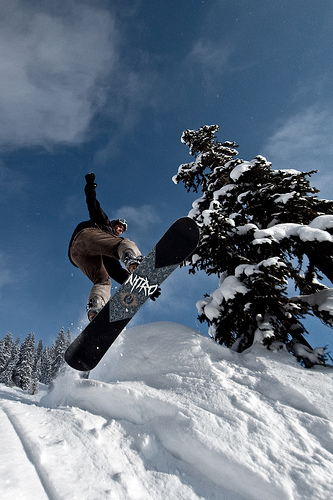

What is the gray and long object that the snowy tree is to the right of?
-------


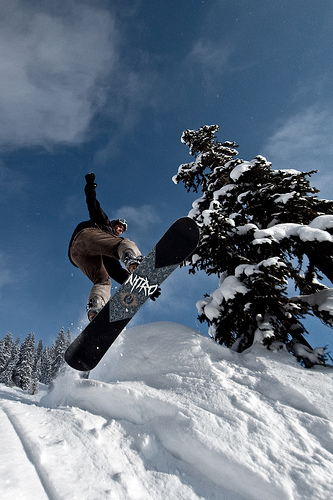

What is the gray and long object that the snowy tree is to the right of?


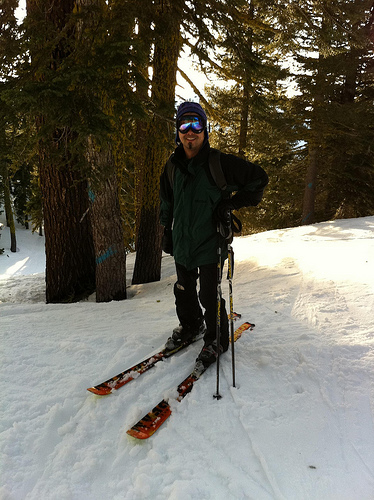

What is the black and thick object that is to the right of the large tree?


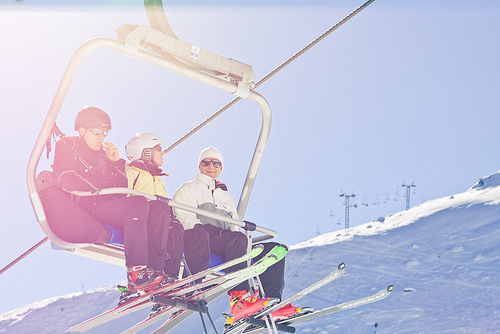

What is the sloped, snowy, and steep object that is to the right of the foot?


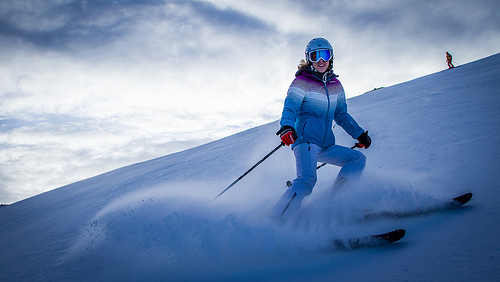

What is the happy and sliding object that is wearing the blue helmet?


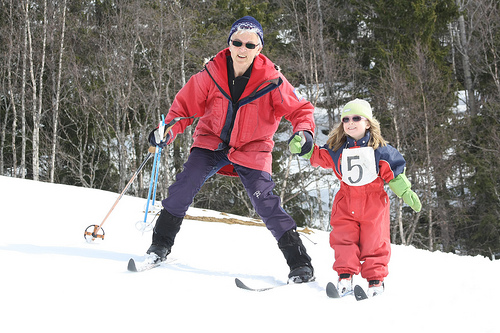

What is the little and skiing object that is to the right of the light gloves?


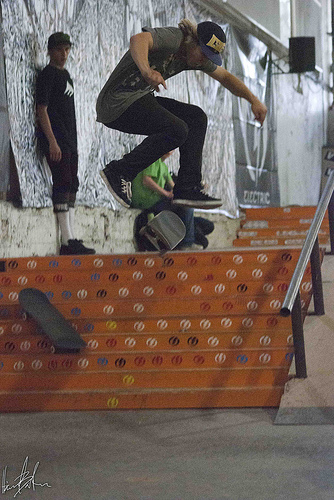

What is the flying and skating object that the short boy is to the left of?


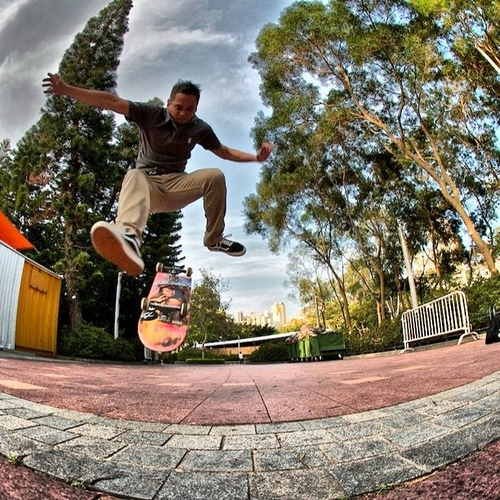

What is the green object that is to the left of the metal and short fence?


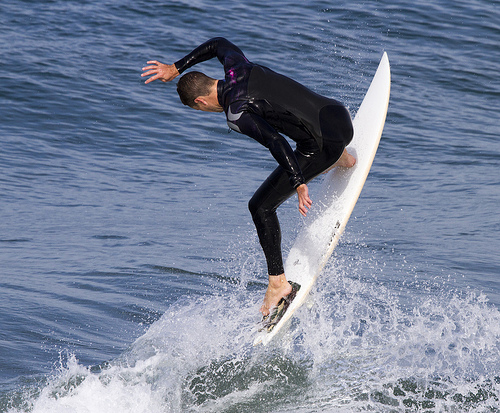

What is the object that is to the left of the dark, short, and wet hair?


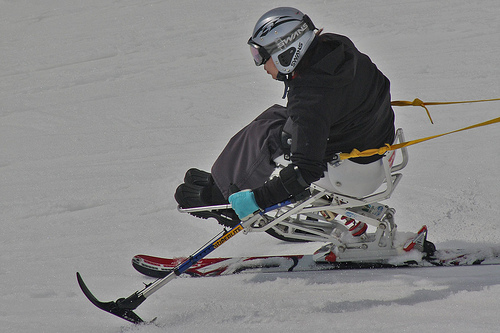

What is the black and ski object that is of the riding person?


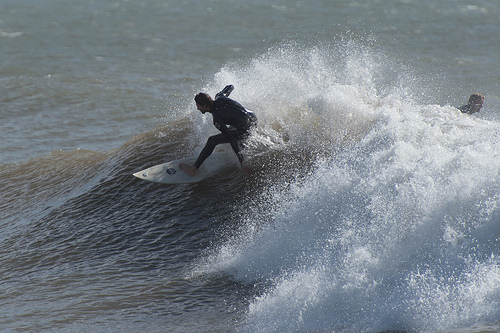

What is the blue, calm, and clear object that is behind the man?


In [46]:
from IPython.display import display

display(stuff_list[1].image_data["image"])
print(stuff_list[1].image_data["question"])
print("-------")
result = hnsw.knn_query(stuff_list[1], k = 10)
for res in result:
    display(res["image"])
    print(res["question"])

## Sample task plans from local parquet file and generate VQA test cases

We can Load the task plans from the local parquet file to a Pandas dataframe by using `pq.read_table(save_path, filters=f).to_pandas().astype(get_pd_schema(generator.schema)` method. After that, we can use `generator.generate()` method to generate VQA test cases based on the task plan.

Above is 3 VQA test cases generated from different types of generators. 

The dataframe below shows the example task plans we used to generated test instances:

The values start with "Q" in the `target category`, `reference category` columns of the returned dataframe is the QID of the category, which corresponds to a Wikidata entry (eg,  `Q11422` corresponds to https://www.wikidata.org/wiki/Q11422).

Note that different question types have different schema, For example, for "what" type question, we don't need count, so the `count` column is `<NA>`.